In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

In [ ]:
class EncodedImageDataset(Dataset):
    def __init__(self, images, weights, traj_joint, traj_task):
        self.images = images
        self.weights = weights
        self.traj_joint = traj_joint
        self.traj_task = traj_task

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        weight = self.weights[idx]
        traj_joint = self.traj_joint[idx]
        traj_task = self.traj_task[idx]
        return image, weight, traj_joint, traj_task

In [ ]:
def custom_collate_fn(batch):
    images, weights, traj_joint, traj_task = zip(*batch)
    images = torch.stack(images)
    weights = torch.stack(weights)

    # Reshape and pad traj_joint
    max_joint_len = max(tj.size(0) for tj in traj_joint)
    max_joint_dim = max(tj.size(-1) for tj in traj_joint)
    padded_traj_joint = torch.zeros(len(traj_joint), max_joint_len, max_joint_dim)

    # Reshape and pad traj_task
    max_task_len = max(tt.size(0) for tt in traj_task)
    max_task_dim = max(tt.size(-1) for tt in traj_task)
    padded_traj_task = torch.zeros(len(traj_task), max_task_len, max_task_dim)

    for i, (tj, tt) in enumerate(zip(traj_joint, traj_task)):
        if tj.dim() == 2:
            padded_traj_joint[i, :tj.size(0), :tj.size(1)] = tj
        elif tj.dim() == 3:
            padded_traj_joint[i, :tj.size(0), :tj.size(2)] = tj.squeeze(1)

        if tt.dim() == 2:
            padded_traj_task[i, :tt.size(0), :tt.size(1)] = tt
        elif tt.dim() == 3:
            padded_traj_task[i, :tt.size(0), :tt.size(2)] = tt.squeeze(1)

    return images, weights, padded_traj_joint, padded_traj_task

In [ ]:
class TransformerDecoderBlock(nn.Module):
    def __init__(self, d_model, nhead, dim_feedforward):
        super(TransformerDecoderBlock, self).__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead)
        self.cross_attn = nn.MultiheadAttention(d_model, nhead)
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.ReLU(),
            nn.Linear(dim_feedforward, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(0.1)

    def forward(self, tgt, memory):
        tgt2 = self.self_attn(tgt, tgt, tgt)[0]
        tgt = tgt + self.dropout(tgt2)
        tgt = self.norm1(tgt)
        tgt2 = self.cross_attn(tgt, memory, memory)[0]
        tgt = tgt + self.dropout(tgt2)
        tgt = self.norm2(tgt)
        tgt2 = self.feed_forward(tgt)
        tgt = tgt + self.dropout(tgt2)
        tgt = self.norm3(tgt)
        return tgt

In [ ]:
class LLMTransformer(nn.Module):
    def __init__(self, d_model, nhead, num_layers, dim_feedforward, output_dim):
        super(LLMTransformer, self).__init__()
        self.embedding = nn.Linear(3, d_model)
        self.pos_encoding = nn.Parameter(torch.randn(1, 1024, d_model))
        self.decoder_layers = nn.ModuleList([
            TransformerDecoderBlock(d_model, nhead, dim_feedforward)
            for _ in range(num_layers)
        ])
        self.fc_out = nn.Linear(d_model, output_dim)

    def forward(self, src):
        # Reshape src to (batch_size, seq_len, channels)
        src = src.permute(0, 2, 3, 1).flatten(1, 2)
        src = self.embedding(src)
        src = src + self.pos_encoding[:, :src.size(1)]

        # Transpose src to (seq_len, batch_size, d_model) for transformer input
        src = src.transpose(0, 1)

        tgt = torch.zeros_like(src)

        for layer in self.decoder_layers:
            tgt = layer(tgt, src)

        # Use the last token's output for prediction
        output = self.fc_out(tgt[-1])
        return output

In [ ]:
def euclidean_loss(predictions, targets):
    return torch.sqrt(torch.sum((predictions - targets) ** 2, dim=1)).mean()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/Data'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load and preprocess data
image_folder = '/content/drive/MyDrive/Data/img_encoded/'
weights_folder = '/content/drive/MyDrive/Data/weights/'
traj_joint_folder = '/content/drive/MyDrive/Data/traj_joint/'
traj_task_folder = '/content/drive/MyDrive/Data/traj_task/'

image_files = [os.path.join(image_folder, file) for file in os.listdir(image_folder) if file.endswith('.jpg')]
encoded_images = [Image.open(file) for file in image_files]
encoded_images = [torch.tensor(np.array(img), dtype=torch.float32).permute(2, 0, 1) for img in encoded_images]

weight_files = [os.path.join(weights_folder, file) for file in os.listdir(weights_folder) if file.endswith('.npy')]
weights = [torch.tensor(np.load(file), dtype=torch.float32) for file in weight_files]

traj_joint_files = [os.path.join(traj_joint_folder, file) for file in os.listdir(traj_joint_folder) if file.endswith('.npy')]
traj_joint_data = [torch.tensor(np.load(file), dtype=torch.float32) for file in traj_joint_files]

traj_task_files = [os.path.join(traj_task_folder, file) for file in os.listdir(traj_task_folder) if file.endswith('.npy')]
traj_task_data = [torch.tensor(np.load(file), dtype=torch.float32) for file in traj_task_files]

dataset = EncodedImageDataset(encoded_images, weights, traj_joint_data, traj_task_data)
train_loader = DataLoader(dataset, batch_size=8, shuffle=True, collate_fn=custom_collate_fn)

In [ ]:
# Hyperparameters
d_model = 256
nhead = 8
num_layers = 6
dim_feedforward = 2048
output_dim = 8
num_epochs = 5
learning_rate = 0.001

In [ ]:
# Initialize the model and optimizer
model = LLMTransformer(d_model, nhead, num_layers, dim_feedforward, output_dim)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
def train_model(model, train_loader, num_epochs, learning_rate):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    losses = []

    for epoch in range(num_epochs):
        total_loss = 0
        for i, (images, weights, traj_joint, traj_task) in enumerate(train_loader):
            optimizer.zero_grad()
            outputs = model(images)
            loss = euclidean_loss(outputs, weights)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            if (i+1) % 10 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

        avg_loss = total_loss / len(train_loader)
        losses.append(avg_loss)
        print(f'Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.4f}')

    return losses

In [ ]:
# Visualization functions
def plot_loss(losses):
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, len(losses) + 1), losses, marker='o')
    plt.title('Training Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Average Loss')
    plt.grid(True)
    plt.show()

def plot_prediction_comparison(model, dataloader):
    model.eval()
    with torch.no_grad():
        images, weights, _, _ = next(iter(dataloader))
        outputs = model(images)

    plt.figure(figsize=(12, 6))
    for i in range(8):
        plt.subplot(2, 4, i+1)
        plt.scatter(weights[:, i].cpu(), outputs[:, i].cpu())
        plt.plot([weights[:, i].min(), weights[:, i].max()], [weights[:, i].min(), weights[:, i].max()], 'r--')
        plt.title(f'Weight {i+1}')
        plt.xlabel('True Value')
        plt.ylabel('Predicted Value')
    plt.tight_layout()
    plt.show()

Epoch [1/5], Step [10/16], Loss: 251.1126
Epoch [1/5], Average Loss: 275.9713
Epoch [2/5], Step [10/16], Loss: 251.4213
Epoch [2/5], Average Loss: 265.9318
Epoch [3/5], Step [10/16], Loss: 254.6538
Epoch [3/5], Average Loss: 257.8516
Epoch [4/5], Step [10/16], Loss: 240.6883
Epoch [4/5], Average Loss: 246.3984
Epoch [5/5], Step [10/16], Loss: 265.7291
Epoch [5/5], Average Loss: 234.9496


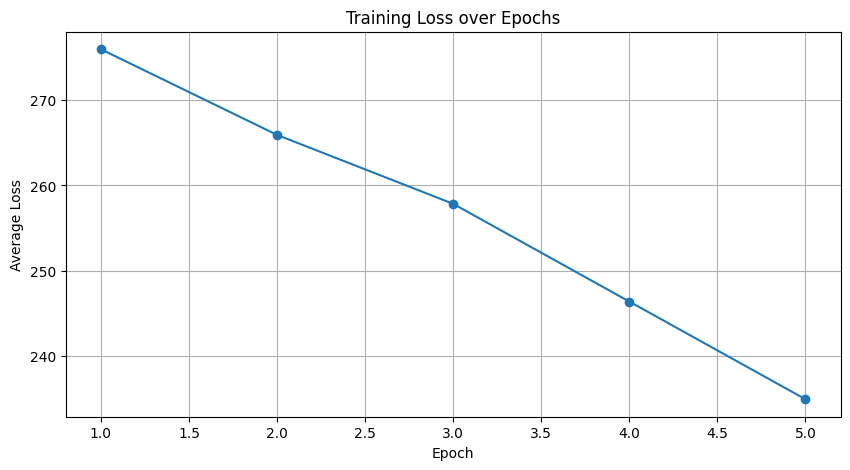

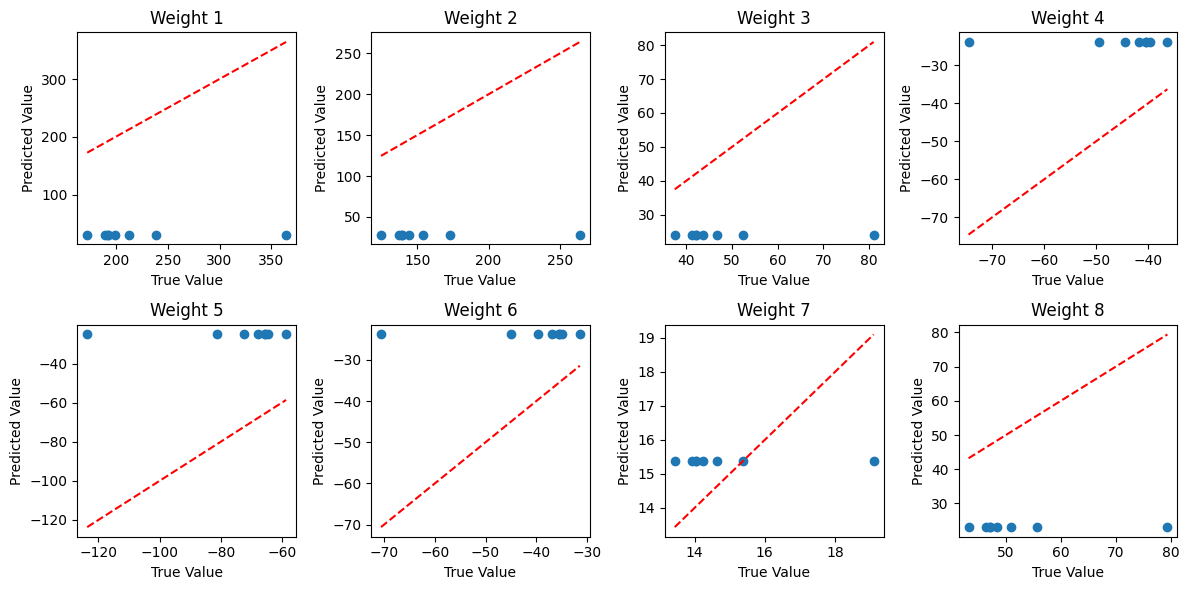

Model saved successfully.


In [ ]:
# Train the model
losses = train_model(model, train_loader, num_epochs, learning_rate)

# Visualize the results
plot_loss(losses)
plot_prediction_comparison(model, train_loader)

# Save the model
torch.save(model.state_dict(), 'llm_transformer_model.pth')
print("Model saved successfully.")